# GRU Eğitimi

Bu notebook, 20 işlem günlük pencerelerle bir sonraki MSFT kapanış fiyatını tahmin eden GRU modelini eğitir. LSTM deneyiyle aynı veri ve hiperparametre koşulları korunur. En düşük validation kaybındaki model ağırlıkları değerlendirme için geri yüklenir. Test dönemi saklı tutulur.

In [1]:
import copy
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from torch import nn
from torch.optim import Adam

from ms_stock_prediction.models import GRUModel, count_trainable_parameters
from ms_stock_prediction.preprocessing import (
    PreparationConfig,
    load_close_prices,
    prepare_time_series,
)
from ms_stock_prediction.training import evaluate_loss, train_one_epoch

SEED = 42
EPOCHS = 50
LEARNING_RATE = 0.001
HIDDEN_SIZE = 32
NUM_LAYERS = 2
BATCH_SIZE = 32
DEVICE = torch.device("cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.style.use("seaborn-v0_8-whitegrid")

## Deney düzeni

- Sabit rastgelelik tohumu: `42`
- Model: 2 katmanlı GRU, 32 gizli birim
- Kayıp fonksiyonu: MSE
- Optimizasyon: Adam, öğrenme oranı `0.001`
- Eğitim süresi: 50 epoch
- Donanım: CPU
- Model seçimi için kullanılan dönem: validation

In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "pyproject.toml").exists():
    raise FileNotFoundError("Proje kökü bulunamadı. Notebook'u proje içinde çalıştırın.")

DATA_PATH = PROJECT_ROOT / "data/raw/msft_daily_latest.csv"
prices = load_close_prices(DATA_PATH)
config = PreparationConfig(lookback=20, batch_size=BATCH_SIZE, shuffle_seed=SEED)
prepared = prepare_time_series(prices, config)

data_summary = pd.DataFrame(
    {
        "Dönem": ["Train", "Validation", "Test (saklı)"],
        "Gözlem": [
            len(prepared.train_prices),
            len(prepared.validation_prices),
            len(prepared.test_prices),
        ],
        "Hedef sayısı": [
            len(prepared.y_train),
            len(prepared.y_validation),
            len(prepared.y_test),
        ],
        "Başlangıç": [
            prepared.train_prices.index.min().date(),
            prepared.validation_prices.index.min().date(),
            prepared.test_prices.index.min().date(),
        ],
        "Bitiş": [
            prepared.train_prices.index.max().date(),
            prepared.validation_prices.index.max().date(),
            prepared.test_prices.index.max().date(),
        ],
    }
)
display(data_summary)

,Dönem,Gözlem,Hedef sayısı,Başlangıç,Bitiş
0,Train,2909,2889,2010-01-04,2021-07-23
1,Validation,623,623,2021-07-26,2024-01-16
2,Test (saklı),624,624,2024-01-17,2026-07-14


## GRU mimarisi

Model her örnekteki 20 kapanış fiyatını sırayla işler ve son zaman adımındaki temsilden tek bir ölçeklenmiş fiyat üretir.

In [3]:
model = GRUModel(
    input_size=1,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    output_size=1,
).to(DEVICE)
loss_function = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=LEARNING_RATE)

print(model)
print(f"Eğitilebilir parametre: {count_trainable_parameters(model):,}")
print(f"Cihaz: {DEVICE}")

GRUModel(
  (recurrent): GRU(1, 32, num_layers=2, batch_first=True)
  (output): Linear(in_features=32, out_features=1, bias=True)
)
Eğitilebilir parametre: 9,729
Cihaz: cpu


## Eğitim

Her epoch sonunda train ve validation MSE kayıpları kaydedilir. Validation kaybı yalnızca değerlendirme amacıyla hesaplanır; bu sırada ağırlıklar güncellenmez. En düşük validation kaybındaki ağırlıklar bellekte saklanır ve metrik hesabından önce geri yüklenir.

In [4]:
history = []
best_validation_loss = float("inf")
best_epoch = 0
best_model_state = None
training_started = time.perf_counter()

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(
        model, prepared.train_loader, optimizer, loss_function, DEVICE
    )
    validation_loss = evaluate_loss(
        model, prepared.validation_loader, loss_function, DEVICE
    )
    history.append(
        {
            "Epoch": epoch,
            "Train MSE (scaled)": train_loss,
            "Validation MSE (scaled)": validation_loss,
        }
    )
    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())
    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train={train_loss:.6f} | validation={validation_loss:.6f}"
    )

training_seconds = time.perf_counter() - training_started
if best_model_state is None:
    raise RuntimeError("Eğitim sırasında geçerli model ağırlığı üretilemedi.")
model.load_state_dict(best_model_state)
history_df = pd.DataFrame(history).set_index("Epoch")
print(f"Eğitim süresi: {training_seconds:.2f} saniye")
print(
    f"Seçilen epoch: {best_epoch} | "
    f"validation={best_validation_loss:.6f}"
)

Epoch 01/50 | train=0.066095 | validation=0.049561


Epoch 02/50 | train=0.000491 | validation=0.035287


Epoch 03/50 | train=0.000462 | validation=0.033304


Epoch 04/50 | train=0.000423 | validation=0.028832


Epoch 05/50 | train=0.000396 | validation=0.026521


...

Epoch 46/50 | train=0.000224 | validation=0.004439


Epoch 47/50 | train=0.000204 | validation=0.004747


Epoch 48/50 | train=0.000180 | validation=0.003634


Epoch 49/50 | train=0.000200 | validation=0.003699


Epoch 50/50 | train=0.000202 | validation=0.002633
Eğitim süresi: 66.29 saniye
Seçilen epoch: 50 | validation=0.002633


,Train MSE (scaled),Validation MSE (scaled)
Epoch,,
1,0.0661,0.0496
2,0.0005,0.0353
3,0.0005,0.0333
4,0.0004,0.0288
5,0.0004,0.0265
6,0.0004,0.0236
7,0.0003,0.0222
8,0.0003,0.0220
9,0.0003,0.0180


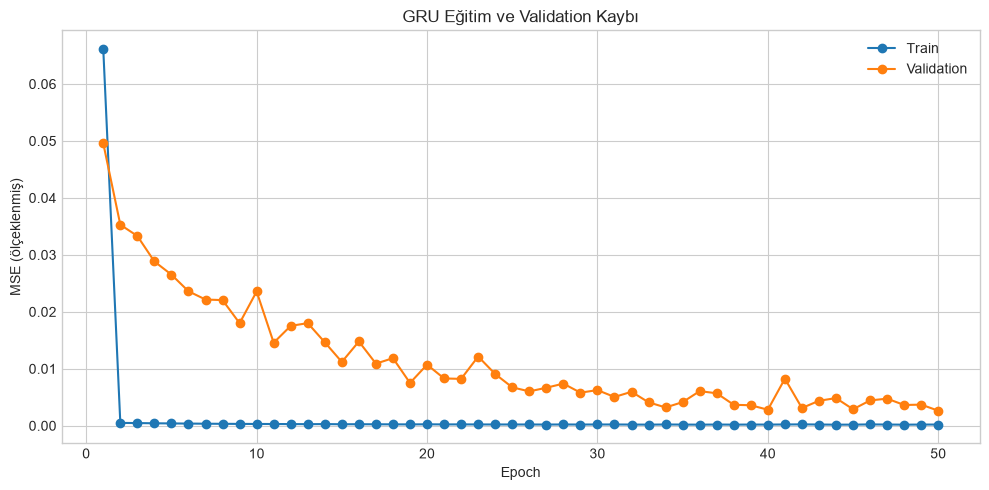

In [5]:
display(history_df)

fig, ax = plt.subplots(figsize=(10, 5))
history_df.plot(ax=ax, marker="o")
ax.set_title("GRU Eğitim ve Validation Kaybı")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE (ölçeklenmiş)")
ax.legend(["Train", "Validation"])
plt.tight_layout()
plt.show()

## Validation sonuçları

Ölçeklenmiş çıktılar dolar ölçeğine geri çevrilir. GRU, her gün için son bilinen kapanışı tahmin kabul eden naive baseline ile aynı validation hedefleri üzerinde karşılaştırılır.

In [6]:
model.eval()
with torch.no_grad():
    predicted_scaled = model(prepared.X_validation.to(DEVICE)).cpu().numpy()

actual_scaled = prepared.y_validation.numpy()
naive_scaled = prepared.X_validation[:, -1, 0].numpy().reshape(-1, 1)

predicted_usd = prepared.scaler.inverse_transform(predicted_scaled).ravel()
actual_usd = prepared.scaler.inverse_transform(actual_scaled).ravel()
naive_usd = prepared.scaler.inverse_transform(naive_scaled).ravel()

def regression_metrics(actual, predicted):
    errors = predicted - actual
    mse = np.mean(errors**2)
    return {
        "MSE (USD²)": mse,
        "RMSE (USD)": np.sqrt(mse),
        "MAE (USD)": np.mean(np.abs(errors)),
    }

metrics_df = pd.DataFrame(
    {
        "GRU": regression_metrics(actual_usd, predicted_usd),
        "Naive baseline": regression_metrics(actual_usd, naive_usd),
    }
).T
display(metrics_df)

,MSE (USD²),RMSE (USD),MAE (USD)
GRU,44.7492,6.6895,5.2316
Naive baseline,24.8756,4.9875,3.7967


In [7]:
assert predicted_scaled.shape == actual_scaled.shape
assert len(predicted_usd) == len(prepared.validation_target_dates)
assert np.isfinite(predicted_usd).all()
assert prepared.validation_target_dates.max() < prepared.test_target_dates.min()

print(f"Validation hedefi: {len(actual_usd):,}")
print(
    "Validation tarihleri: "
    f"{prepared.validation_target_dates.min().date()} - "
    f"{prepared.validation_target_dates.max().date()}"
)
print("Test dönemine ait tahmin veya metrik hesaplanmadı.")

Validation hedefi: 623
Validation tarihleri: 2021-07-26 - 2024-01-16
Test dönemine ait tahmin veya metrik hesaplanmadı.


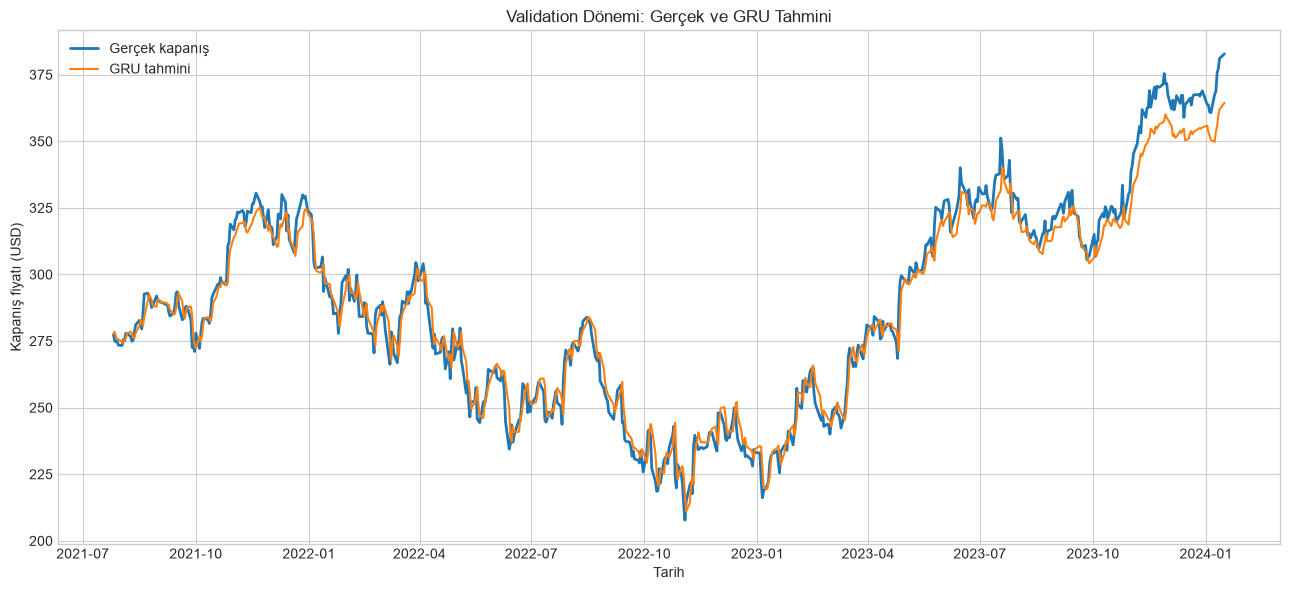

In [8]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(
    prepared.validation_target_dates,
    actual_usd,
    label="Gerçek kapanış",
    linewidth=2,
)
ax.plot(
    prepared.validation_target_dates,
    predicted_usd,
    label="GRU tahmini",
    linewidth=1.5,
)
ax.set_title("Validation Dönemi: Gerçek ve GRU Tahmini")
ax.set_xlabel("Tarih")
ax.set_ylabel("Kapanış fiyatı (USD)")
ax.legend()
plt.tight_layout()
plt.show()

## Validation değerlendirmesi

Aşağıdaki çıktı, seçilen GRU ağırlıkları ile naive baseline arasındaki RMSE farkını özetler. Pozitif fark GRU'nun daha yüksek, negatif fark daha düşük hata ürettiğini gösterir.

In [9]:
gru_rmse = metrics_df.loc["GRU", "RMSE (USD)"]
naive_rmse = metrics_df.loc["Naive baseline", "RMSE (USD)"]
rmse_difference = gru_rmse - naive_rmse

print(f"GRU validation RMSE: {gru_rmse:.4f} USD")
print(f"Naive validation RMSE: {naive_rmse:.4f} USD")
print(f"RMSE farkı (GRU - naive): {rmse_difference:+.4f} USD")

GRU validation RMSE: 6.6895 USD
Naive validation RMSE: 4.9875 USD
RMSE farkı (GRU - naive): +1.7019 USD
